In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import normal_ad
from scipy.stats import shapiro

In [3]:
#df=pd.read_csv('./iq.csv')

In [15]:
url="https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/2.%20Distribuciones%20y%20varianzas%20de%20grupos/2.3%20Analizando%20distribuciones%20en%20grupos%20en%20Python/iq.csv"

In [16]:
df = pd.read_csv(url)

In [17]:
df.head()

,IQ,School
0,147.0,2.0
1,140.0,2.0
2,141.0,1.0
3,141.0,1.0
4,142.0,2.0


In [18]:
group1=df[df.School==1.0]
group2=df[df.School==2.0]
group1.head()

,IQ,School
2,141.0,1.0
3,141.0,1.0
5,146.0,1.0
7,146.0,1.0
8,145.0,1.0


In [19]:
mean1=group1.IQ.mean() #149
mean2=group2.IQ.mean() #146.7

In [20]:
res1=group1.IQ - mean1
res2=group2.IQ - mean2

------------------First School------------------ 

Using the Anderson-Darling test for normal distribution
p-value from the test - below 0.05 generally means non-normal: 0.00031705273647239117
Residuals are not normally distributed 

Using the Shapiro-Wilks test for normal distribution
p-value from the test - below 0.05 generally means non-normal: 0.000939472253955561
Residuals are not normally distributed


/tmp/ipykernel_8123/567868344.py:31: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res1)


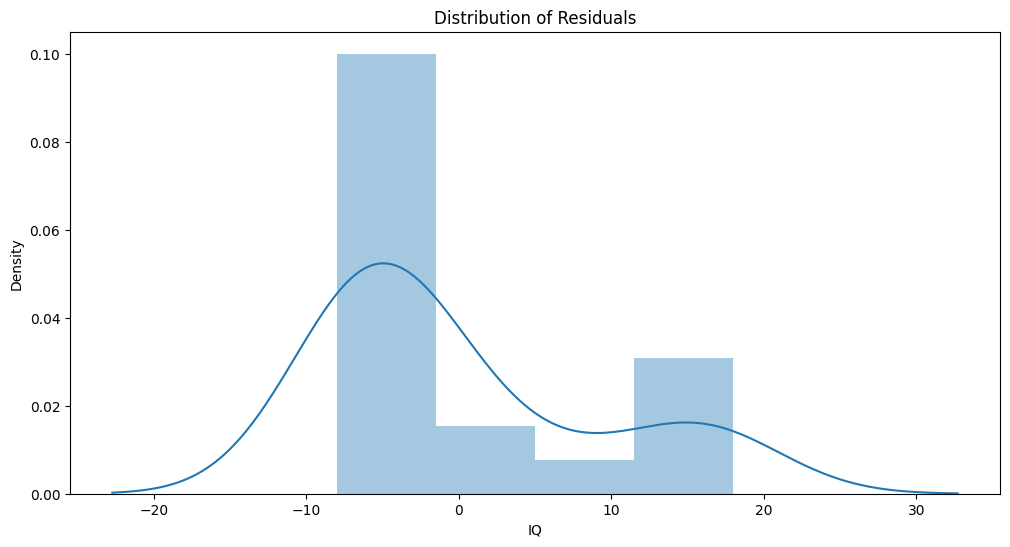


Assumption not satisfied

Confidence intervals will likely be affected
Try performing nonlinear transformations on variables 

------------------Second School------------------ 

Using the Anderson-Darling test for normal distribution
p-value from the test - below 0.05 generally means non-normal: 0.01668376405845095
Residuals are not normally distributed 

Using the Shapiro-Wilks test for normal distribution
p-value from the test - below 0.05 generally means non-normal: 0.0037090974862783073
Residuals are not normally distributed


/tmp/ipykernel_8123/567868344.py:74: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res2)


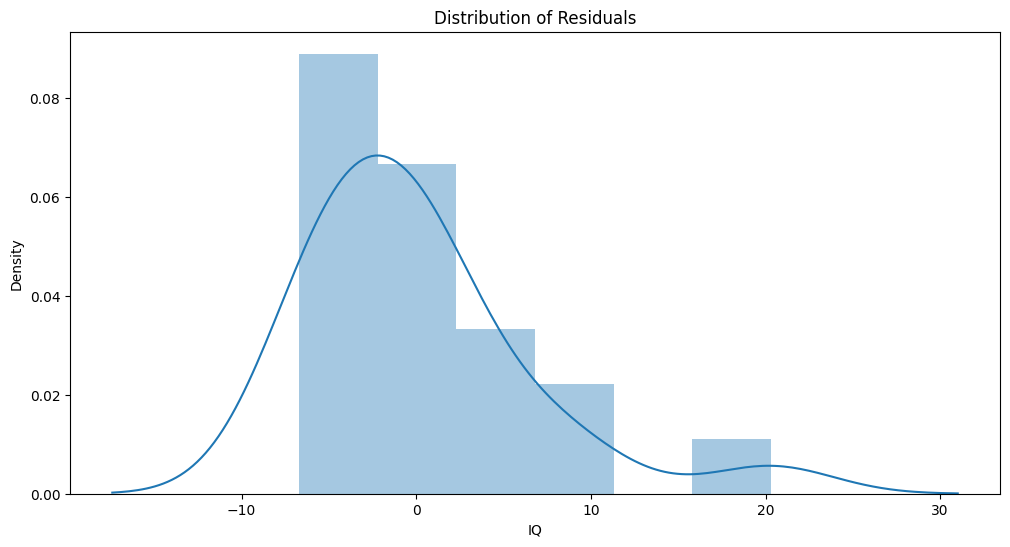


Assumption not satisfied

Confidence intervals will likely be affected
Try performing nonlinear transformations on variables


In [21]:
    # Performing the test on the residuals
    p_value_thresh=0.05
    print('------------------First School------------------','\n')

    print('Using the Anderson-Darling test for normal distribution')

    p_value = normal_ad(res1)[1]
    print('p-value from the test - below 0.05 generally means non-normal:', p_value)

    # Reporting the normality of the residuals
    if p_value < p_value_thresh:
        print('Residuals are not normally distributed', '\n')
    else:
        print('Residuals are normally distributed', '\n')

    print('Using the Shapiro-Wilks test for normal distribution')
    shapiro_test = shapiro(res1)
    shapiro_test_stat=shapiro_test[0]
    shapiro_test_pvalue=shapiro_test[1]
    print('p-value from the test - below 0.05 generally means non-normal:', shapiro_test_pvalue)

    # Reporting the normality of the residuals
    if shapiro_test_pvalue < p_value_thresh:
        print('Residuals are not normally distributed')
    else:
        print('Residuals are normally distributed')

    # Plotting the residuals distribution
    plt.subplots(figsize=(12, 6))
    plt.title('Distribution of Residuals')
    sns.distplot(res1)
    plt.show()

    print()
    if p_value > p_value_thresh:
        print('Assumption satisfied', '\n')
    else:
        print('Assumption not satisfied')
        print()
        print('Confidence intervals will likely be affected')
        print('Try performing nonlinear transformations on variables', '\n')

#################################################################################################
    # Performing the test on the residuals
    p_value_thresh=0.05
    print('------------------Second School------------------','\n')

    print('Using the Anderson-Darling test for normal distribution')

    p_value = normal_ad(res2)[1]
    print('p-value from the test - below 0.05 generally means non-normal:', p_value)

    # Reporting the normality of the residuals
    if p_value < p_value_thresh:
        print('Residuals are not normally distributed', '\n')
    else:
        print('Residuals are normally distributed', '\n')

    print('Using the Shapiro-Wilks test for normal distribution')
    shapiro_test = stats.shapiro(res2)
    shapiro_test_stat=shapiro_test[0]
    shapiro_test_pvalue=shapiro_test[1]
    print('p-value from the test - below 0.05 generally means non-normal:', shapiro_test_pvalue)

    # Reporting the normality of the residuals
    if shapiro_test_pvalue < p_value_thresh:
        print('Residuals are not normally distributed')
    else:
        print('Residuals are normally distributed')

    # Plotting the residuals distribution
    plt.subplots(figsize=(12, 6))
    plt.title('Distribution of Residuals')
    sns.distplot(res2)
    plt.show()

    print()
    if p_value > p_value_thresh:
        print('Assumption satisfied')
    else:
        print('Assumption not satisfied')
        print()
        print('Confidence intervals will likely be affected')
        print('Try performing nonlinear transformations on variables')

